In [2]:
from scipy import constants as const
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Crystals

The major contributing forces to the cohesive energy of an ionic crystal such as NaCl is the ion-ion negative potential $\large -\alpha \frac{q^2}{4\pi \epsilon_0 R}$, the energy difference between free ions and free neutral atoms $I_{Na} - Aff_{Cl}$, and the repulsive forces caused by the nucleui and Pauli replusion $AR^{-n}$. Combining these gives $\large U = I_{Na} - Aff_{Cl} -\alpha \frac{q^2}{4\pi \epsilon_0 R} + AR^{-n}$. Setting $dU/dR = 0$ gives $\large R_0=\left(\frac{nA}{\alpha q^2/(4\pi\epsilon_0)}\right)^{\frac{1}{n-1}}$.

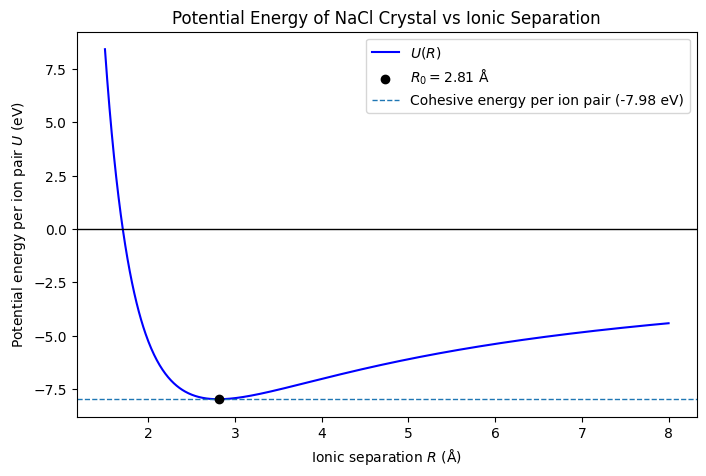

In [33]:
# For NaCl, the values of some of the constants are given below
I_Na = 5.14 # eV
Aff_Cl = 6.45 # eV
alpha = 1.75 # Madelung constant
K = 14.4 # eV Angstrom, equal to q^2/(4 pi epsilon_0)
n = 3.90
A = 129 # eV * Angstrom^n

def U(R):
    return I_Na - Aff_Cl - alpha * K / R + A * R**(-n)

# R values in Angstroms (x values)
R = np.linspace(1.5, 8.0, 1000)

U_values = U(R) # y values

# Equilibrium separation
R0 = 2.81
U0 = U(R0)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(R, U_values, label=r"$U(R)$", color='b')
plt.scatter(R0, U0, color="black", zorder=3, label=fr"$R_0 = {R0}$ Å")

plt.axhline(0, color="k", linewidth=1)
plt.axhline(-7.98, linestyle='--', linewidth=1, label='Cohesive energy per ion pair (-7.98 eV)')

plt.xlabel(r"Ionic separation $R$ (Å)")
plt.ylabel(r"Potential energy per ion pair $U$ (eV)")
plt.title("Potential Energy of NaCl Crystal vs Ionic Separation")
plt.legend();

The Madelung constant can be calculated for an NaCl crystal by indexing all the points within the face-centered crystal (iR, jR, kR) and summing over each indices contribution $\large \pm q^2/(4\pi \epsilon_0R\sqrt{i^2+j^2+k^2})$. This way of calculating the Madelung constant calculates each cubic layer which causes the constant to converge around 1.748, but if you were instead to expand out in spheres, the consant would diverge. This makes it much more pratical (and correct) for computationally calculating the Madelung constant.

Madelung constant for r = 1: 2.134
Madelung constant for r = 5: 1.853
Madelung constant for r = 10: 1.693
Madelung constant for r = 20: 1.719


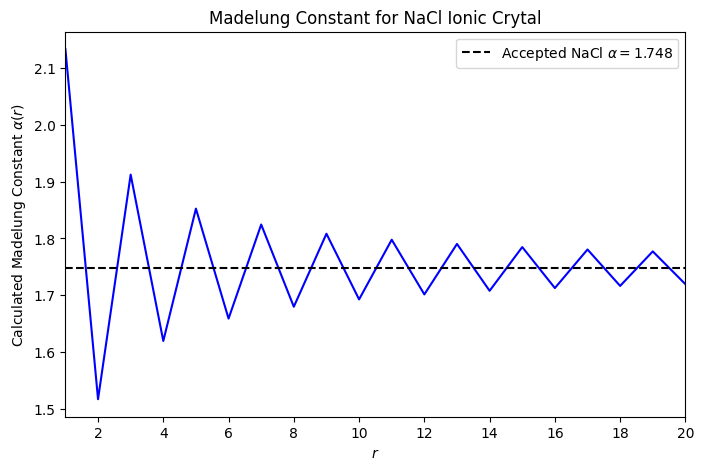

In [24]:
def madelung_const(r):
    alpha = 0.0
    for i in range(-r, r + 1):
        for j in range (-r, r + 1):
            for k in range (-r, r + 1):
                #skips if i=j=k=0 as this is the origin
                if (i == 0 and j == 0 and k == 0):
                    continue

                #The relative charge is opposite if i + j + k is odd and the same if that sum is even
                relative_charge = (-1)**(i + j + k)
                distance = np.sqrt((i**2) + (j**2) + (k**2))

                alpha -= relative_charge / distance
    return alpha

print(f"Madelung constant for r = 1: {madelung_const(1):0.3f}")
print(f"Madelung constant for r = 5: {madelung_const(5):0.3f}")
print(f"Madelung constant for r = 10: {madelung_const(10):0.3f}")
print(f"Madelung constant for r = 20: {madelung_const(20):0.3f}")

r_vals = np.arange(1, 21) # x-vals
Madelung_vals = np.array([madelung_const(r) for r in r_vals])

plt.figure(figsize=(8, 5))
plt.plot(r_vals, Madelung_vals, color='b')
plt.axhline(1.748, linestyle='--', label=r'Accepted NaCl $\alpha=1.748$', color='k')

plt.xlabel("$r$")
plt.ylabel(r"Calculated Madelung Constant $\alpha(r)$")
plt.title("Madelung Constant for NaCl Ionic Crytal")

plt.xticks(np.arange(0, 21, 2))
plt.xlim(1,20)
plt.legend();